# Fashion-MNIST Dataset - Vision Transformer

### [Fashion-MNIST Dataset](https://github.com/zalandoresearch/fashion-mnist)

Author: [Kevin Thomas](mailto:ket189@pitt.edu)

License: MIT

## Citation

[1] Han Xiao, Kashif Rasul, Roland Vollgraf, https://github.com/zalandoresearch/fashion-mnist

[2] Alexey Dosovitskiy et al., https://arxiv.org/abs/2010.11929

## Install Libraries

In [1]:
# conda activate prod
# conda install -c conda-forge pytorch torchvision torchaudio
# conda install numpy matplotlib scikit-learn

## Import Libraries

In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision import transforms
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

## Seed

In [3]:
SEED = 42
SEED

42

In [4]:
torch.manual_seed(SEED)

## Parameters

In [5]:
IMAGE_SIZE = 28
IMAGE_SIZE

28

In [6]:
PATCH_SIZE = 4
PATCH_SIZE

4

In [7]:
EMBED_DIM = 64
EMBED_DIM

64

In [8]:
N_HEADS = 4
N_HEADS

4

In [9]:
N_LAYERS = 4
N_LAYERS

4

In [10]:
FF_DIM = 128
FF_DIM

128

In [11]:
NUM_CLASSES = 10
NUM_CLASSES

10

In [12]:
CLASS_NAMES = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
CLASS_NAMES

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

## Hyperparameters

In [13]:
LEARNING_RATE = 0.001
LEARNING_RATE

0.001

In [14]:
EPOCHS = 8
EPOCHS

8

In [15]:
BATCH_SIZE = 128
BATCH_SIZE

128

## Device

In [16]:
DEVICE = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu")
DEVICE

device(type='mps')

## Load Dataset

In [17]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.2860,), (0.3530,))])
train_data = datasets.FashionMNIST('data', train=True, download=True, transform=transform)
test_data = datasets.FashionMNIST('data', train=False, download=True, transform=transform)
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False)
len(train_data), len(test_data)

(60000, 10000)

## Create Patch Embedding

The image is cut into non-overlapping patches. Each patch is flattened and projected to an embedding vector by a linear layer.

In [18]:
class PatchEmbedding(nn.Module):
    """
    Split an image into patches and embed each patch with a linear layer.
    """

    def __init__(self, embed_dim=EMBED_DIM, patch_size=PATCH_SIZE):
        """
        Initialize the patch projection.

        Parameters:
            embed_dim (int): Embedding size per patch.
            patch_size (int): Side length of each patch.

        Returns:
            None
        """
        super(PatchEmbedding, self).__init__()
        self.patch_size = patch_size
        self.proj = nn.Linear(patch_size * patch_size, embed_dim)

    def forward(self, x):
        """
        Embed a batch of grayscale images.

        Parameters:
            x (torch.Tensor): Batch of images.

        Returns:
            torch.Tensor: Patch embeddings.
        """
        batch, channels, height, width = x.shape
        p = self.patch_size
        x = x.reshape(batch, channels, height // p, p, width // p, p)
        x = x.permute(0, 2, 4, 1, 3, 5).reshape(batch, (height // p) * (width // p), -1)
        return self.proj(x)

## Create Transformer Encoder

In [19]:
class Attention(nn.Module):
    """
    Multi-head self-attention built from explicit tensor operations.
    """

    def __init__(self, embed_dim=EMBED_DIM, n_heads=N_HEADS):
        """
        Initialize the query, key, value, and output projections.

        Parameters:
            embed_dim (int): Embedding size.
            n_heads (int): Number of attention heads.

        Returns:
            None
        """
        super(Attention, self).__init__()
        self.n_heads = n_heads
        self.head_dim = embed_dim // n_heads
        self.qkv = nn.Linear(embed_dim, 3 * embed_dim)
        self.proj = nn.Linear(embed_dim, embed_dim)

    def forward(self, x):
        """
        Run multi-head self-attention.

        Parameters:
            x (torch.Tensor): Input of shape (batch, tokens, embed_dim).

        Returns:
            torch.Tensor: Attention output.
        """
        batch, tokens, embed_dim = x.shape
        qkv = self.qkv(x).reshape(batch, tokens, 3, self.n_heads, self.head_dim)
        query, key, value = qkv.permute(2, 0, 3, 1, 4)
        out = F.scaled_dot_product_attention(query, key, value)
        out = out.transpose(1, 2).reshape(batch, tokens, embed_dim)
        return self.proj(out)

In [20]:
class EncoderBlock(nn.Module):
    """
    A transformer encoder block with attention and a feed-forward network.
    """

    def __init__(self, embed_dim=EMBED_DIM, n_heads=N_HEADS, ff_dim=FF_DIM):
        """
        Initialize attention, normalization, and feed-forward layers.

        Parameters:
            embed_dim (int): Embedding size.
            n_heads (int): Number of attention heads.
            ff_dim (int): Feed-forward hidden size.

        Returns:
            None
        """
        super(EncoderBlock, self).__init__()
        self.attn = Attention(embed_dim, n_heads)
        self.norm1 = nn.LayerNorm(embed_dim)
        self.ff = nn.Sequential(
            nn.Linear(embed_dim, ff_dim),
            nn.GELU(),
            nn.Linear(ff_dim, embed_dim))
        self.norm2 = nn.LayerNorm(embed_dim)

    def forward(self, x):
        """
        Run the encoder block with residual connections.

        Parameters:
            x (torch.Tensor): Input of shape (batch, tokens, embed_dim).

        Returns:
            torch.Tensor: Output of the same shape.
        """
        x = self.norm1(x + self.attn(x))
        return self.norm2(x + self.ff(x))

## Create Vision Transformer

In [21]:
class ViT(nn.Module):
    """
    A small vision transformer for 28x28 grayscale images.
    """

    def __init__(self, embed_dim=EMBED_DIM, n_heads=N_HEADS, n_layers=N_LAYERS,
                 ff_dim=FF_DIM, patch_size=PATCH_SIZE, num_classes=NUM_CLASSES):
        """
        Initialize patch embedding, tokens, blocks, and the head.

        Parameters:
            embed_dim (int): Embedding size.
            n_heads (int): Number of attention heads.
            n_layers (int): Number of encoder blocks.
            ff_dim (int): Feed-forward hidden size.
            patch_size (int): Side length of each patch.
            num_classes (int): Number of output classes.

        Returns:
            None
        """
        super(ViT, self).__init__()
        self.patch = PatchEmbedding(embed_dim, patch_size)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(
            torch.zeros(1, (IMAGE_SIZE // patch_size) ** 2 + 1, embed_dim))
        self.blocks = nn.Sequential(*[
            EncoderBlock(embed_dim, n_heads, ff_dim) for _ in range(n_layers)])
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        """
        Classify a batch of images.

        Parameters:
            x (torch.Tensor): Batch of images.

        Returns:
            torch.Tensor: Output logits.
        """
        x = self.patch(x)
        cls = self.cls_token.expand(x.size(0), -1, -1)
        x = torch.cat([cls, x], dim=1) + self.pos_embed
        x = self.blocks(x)
        return self.head(self.norm(x[:, 0]))

## Instantiate Model, Loss, and Optimizer

In [22]:
torch.manual_seed(SEED)
model = ViT().to(DEVICE)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
sum(p.numel() for p in model.parameters())

139018

## Train Model

### Functions

In [23]:
def train_epoch(model, loader, loss_fn, optimizer):
    """
    Train the model for a single epoch.

    Parameters:
        model (nn.Module): The model to train.
        loader (DataLoader): Training data loader.
        loss_fn (nn.Module): Loss function.
        optimizer (torch.optim.Optimizer): Parameter update rule.

    Returns:
        float: Mean training loss.
    """
    model.train()
    total = 0.0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        loss = loss_fn(model(x), y)
        loss.backward()
        optimizer.step()
        total += loss.item() * len(y)
    return total / len(loader.dataset)


def evaluate(model, loader, loss_fn):
    """
    Evaluate the model over a loader.

    Parameters:
        model (nn.Module): The model to evaluate.
        loader (DataLoader): Evaluation data loader.
        loss_fn (nn.Module): Loss function.

    Returns:
        tuple: Mean loss and accuracy.
    """
    model.eval()
    total, correct = 0.0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            logits = model(x)
            total += loss_fn(logits, y).item() * len(y)
            correct += (logits.argmax(1) == y).sum().item()
    n = len(loader.dataset)
    return total / n, correct / n

### Training Loop

In [24]:
history = {'loss': [], 'accuracy': []}
for epoch in range(EPOCHS):
    train_loss = train_epoch(model, train_loader, loss_fn, optimizer)
    test_loss, test_accuracy = evaluate(model, test_loader, loss_fn)
    history['loss'].append(test_loss)
    history['accuracy'].append(test_accuracy)
    print(f"Epoch {epoch + 1} | train loss {train_loss:.4f} | test accuracy {test_accuracy:.4f}")

Epoch 1 | train loss 0.7988 | test accuracy 0.8157


Epoch 2 | train loss 0.4420 | test accuracy 0.8441


Epoch 3 | train loss 0.3857 | test accuracy 0.8607


Epoch 4 | train loss 0.3518 | test accuracy 0.8652


Epoch 5 | train loss 0.3254 | test accuracy 0.8710


Epoch 6 | train loss 0.3059 | test accuracy 0.8698


Epoch 7 | train loss 0.2883 | test accuracy 0.8755


Epoch 8 | train loss 0.2745 | test accuracy 0.8729


### Visualize Training

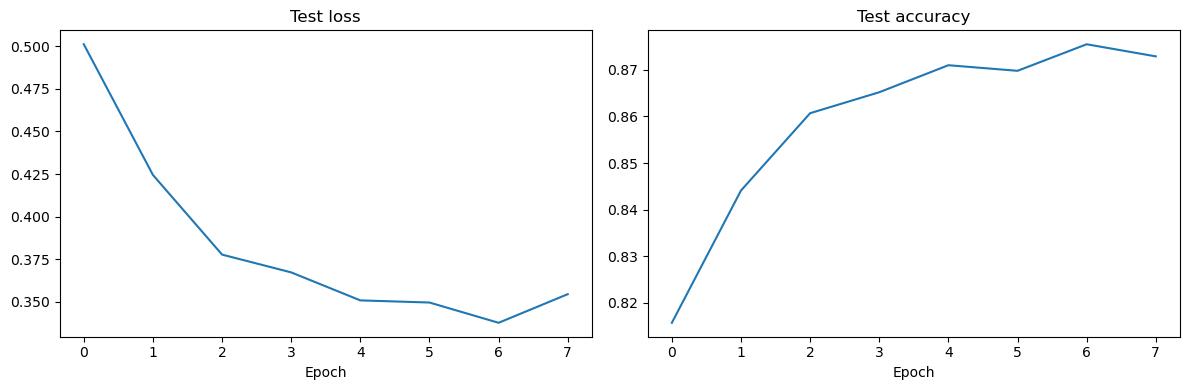

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history['loss'])
axes[0].set_title('Test loss')
axes[0].set_xlabel('Epoch')
axes[1].plot(history['accuracy'])
axes[1].set_title('Test accuracy')
axes[1].set_xlabel('Epoch')
fig.tight_layout()
plt.show()

## Evaluate Model

In [26]:
_, accuracy = evaluate(model, test_loader, loss_fn)
print(f"Test accuracy: {accuracy:.4f}")

Test accuracy: 0.8729


In [27]:
all_preds = []
all_labels = []
model.eval()
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(DEVICE)
        all_preds.append(model(x).argmax(1).cpu().numpy())
        all_labels.append(y.numpy())
all_preds = np.concatenate(all_preds)
all_labels = np.concatenate(all_labels)
print(confusion_matrix(all_labels, all_preds))
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

[[814   2  12   6   1   1 159   0   5   0]
 [  4 981   1   5   4   0   4   0   1   0]
 [ 23   1 814   4  51   0 105   0   2   0]
 [ 51  13   8 805  33   0  90   0   0   0]
 [  0   0 123  18 739   0 118   0   2   0]
 [  1   0   0   0   0 930   1  53   7   8]
 [111   3  56  10  45   0 768   0   7   0]
 [  0   0   0   0   0   6   0 979   1  14]
 [  8   2   1   4   2   3  20   3 957   0]
 [  1   0   0   0   0   3   0  54   0 942]]
              precision    recall  f1-score   support

 T-shirt/top       0.80      0.81      0.81      1000
     Trouser       0.98      0.98      0.98      1000
    Pullover       0.80      0.81      0.81      1000
       Dress       0.94      0.81      0.87      1000
        Coat       0.84      0.74      0.79      1000
      Sandal       0.99      0.93      0.96      1000
       Shirt       0.61      0.77      0.68      1000
     Sneaker       0.90      0.98      0.94      1000
         Bag       0.97      0.96      0.97      1000
  Ankle boot       0.98     

## Save Model

In [28]:
torch.save(model.state_dict(), 'vit_fashion_mnist.pt')
print('saved vit_fashion_mnist.pt')

saved vit_fashion_mnist.pt


## Load Model

In [29]:
loaded_model = ViT().to(DEVICE)
loaded_model.load_state_dict(torch.load('vit_fashion_mnist.pt', map_location=DEVICE))
loaded_model.eval()
print('loaded vit_fashion_mnist.pt')

loaded vit_fashion_mnist.pt


/var/folders/qg/60m3b34x32gczgr10l3665300000gn/T/ipykernel_55772/3325605801.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded_model.load_state_dict(torch.load('vit_

## Inference

### Function

In [30]:
def predict(model, image):
    """
    Predict the class of one normalized image tensor.

    Parameters:
        model (nn.Module): Trained model.
        image (torch.Tensor): A 1x28x28 image tensor.

    Returns:
        tuple: Predicted class name and confidence.
    """
    model.eval()
    with torch.no_grad():
        logits = model(image.unsqueeze(0).to(DEVICE))
        probs = torch.softmax(logits, dim=1)
        confidence, predicted = probs.max(dim=1)
    return CLASS_NAMES[predicted.item()], confidence.item()

### Run Inference

True: Sneaker | Predicted: Sandal (0.6848)


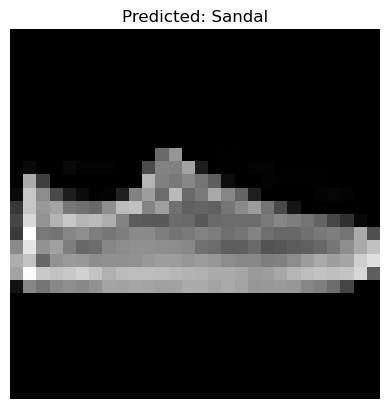

In [31]:
image, label = test_data[12]
name, confidence = predict(loaded_model, image)
print(f"True: {CLASS_NAMES[label]} | Predicted: {name} ({confidence:.4f})")
plt.imshow(image.squeeze(), cmap='gray')
plt.title(f"Predicted: {name}")
plt.axis('off')
plt.show()